3.1 Precipation data

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import seaborn as sns
from scipy.interpolate import griddata

# For a more classic red-green relief map change this to True:
classic_relief = False

# Exploration of the data's encoding:
!curl -s "https://opendata.dwd.de/climate_environment/CDC/helprr_wetter_tageswerte_Beschreibung_Stationen.txt" | file -

/dev/stdin: ISO-8859 text, with very long lines (1000), with CRLF line terminators


In [40]:
# 1.1 DATA CLEANING

# Downloading the data, converting it to utf-8, and removing carriage return characters for proper handling of DOS Format:
!curl -s "https://opendata.dwd.de/climate_environment/CDC/helprr_wetter_tageswerte_Beschreibung_Stationen.txt" | iconv -f iso-8859-1 -t utf-8 | tr -d '\r' > stations.txt

STATES = ['Baden-Württemberg', 'Bayern', 'Berlin', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen']

# Converting .txt file to Pandas DataFrame for easier manipulation:
rows = []
with open('stations.txt', encoding='utf-8') as stations_f:
    for line in stations_f:
        line = line.strip()
        parts = line.split(None, 6)     # Splitting numerical entries by whitespace.
        if len(parts) > 6:
            remaining = parts[6]
            # Finding the earliest occurrence of any state name in the remaining text:
            seventh_idx = -1
            for marker in STATES:
                idx = remaining.find(marker)
                if idx != -1 and (seventh_idx == -1 or idx < seventh_idx):
                    seventh_idx = idx
            # Splitting sixth from seventh column:
            if seventh_idx != -1:
                parts[6] = remaining[:seventh_idx].strip()
                state_text = remaining[seventh_idx:].strip()
                # Cleaning last column to contain nothing but state names:
                for state in STATES:
                    if state_text.startswith(state):
                        parts.append(state)
                        break
        rows.append(parts)
stations_df = pd.DataFrame(rows).set_index(0)   # Setting index.

# Adjusting header:
stations_df.columns = stations_df.iloc[0]
stations_df = stations_df.iloc[2:]
stations_df.columns.values[-1] = 'Bundesland'
stations_df.columns.values[-2] = 'Stationsname'

# Converting numerical columns to appropriate data types:
stations_df.index = stations_df.index.astype('int64')
stations_df = stations_df.astype({
    stations_df.columns[0]: 'int64',
    stations_df.columns[1]: 'int64',
    stations_df.columns[2]: 'int64',
    stations_df.columns[3]: 'int64',
    'geoBreite': 'float64',
    'geoLaenge': 'float64'
})

# Converting Pandas DataFrame to .csv file:
stations_df.to_csv('stations.csv', index=False)

# Exploration of elevation data:
print(stations_df['Stationshoehe'].describe())

count    5311.000000
mean      288.349275
std       239.154753
min        -1.000000
25%        80.000000
50%       252.000000
75%       437.000000
max      2956.000000
Name: Stationshoehe, dtype: float64


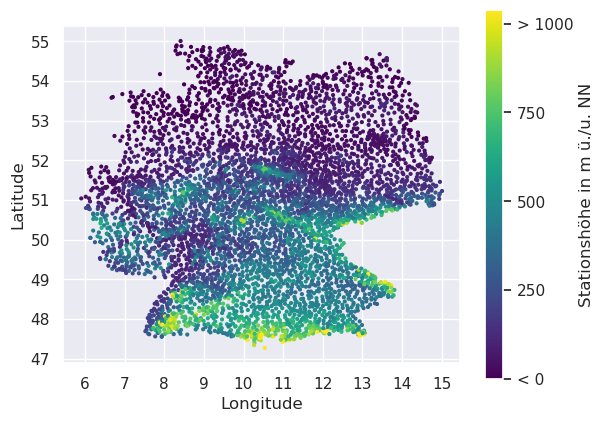

In [41]:
# 1.2 PLOT

# Based on the description above it seems sensible to exclude some of the highest stations from the colormapping process to prevent them from dominating the color range as most stations are located at rather low elevations. We choose to mark the 0.5% highest stations as "outliers".

# Excluding outliers from colormapping norm:
elevations = stations_df['Stationshoehe'].to_numpy()
outliers = np.argsort(elevations)[-int(len(elevations)/200):]
elev_wo_outliers = np.delete(elevations, outliers)
norm = colors.Normalize(vmin=np.min(elev_wo_outliers), vmax=np.max(elev_wo_outliers))

# Plot:
sns.set_theme()
fig, ax = plt.subplots()
colmap = 'RdYlGn_r' if classic_relief else 'viridis'
sc = ax.scatter(stations_df['geoLaenge'], stations_df['geoBreite'], s=4, c=elevations, cmap=colmap, norm=norm)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Displaying the map equidistantly as we are lacking an actual projected coordinate system:
ax.set_aspect('equal')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
cbar = fig.colorbar(sc, ax=ax, label='Stationshöhe in m ü./u. NN')
cbar.set_ticks(np.linspace(0, 1000, 5))
cbar.set_ticklabels(['< 0', '250', '500', '750','> 1000'])
plt.show()

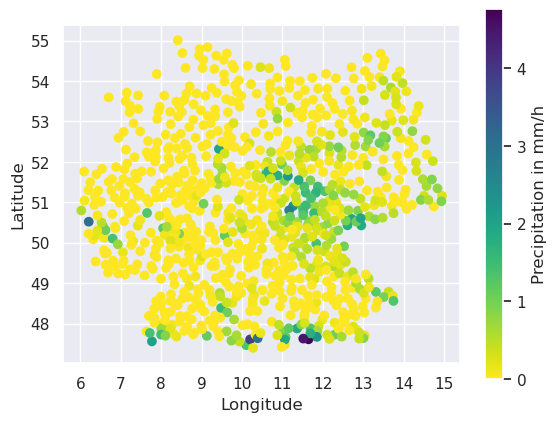

In [42]:
# 2.

# Converting .csv table into Pandas DataFrame:
precipation_df = pd.read_csv('10min_processed.csv')

# Truncating missing values:
precipation_df['rain'] = precipation_df['rain'].clip(lower=0)

# Computing precipation by hour:
precipation_df['date'] = precipation_df['date'] // 100
precipation_df = precipation_df.groupby(['date', 'stationid']).agg({
    'rain': 'sum',
}).reset_index()

# Merging with station data to get coordinates:
precipation_df = precipation_df.merge(stations_df[['geoBreite', 'geoLaenge']], left_on='stationid', right_on=stations_df.index)

# Picking out the data for the 20th of April 2024 at midnight:
midnight_20th_precipation = precipation_df[precipation_df['date'] == 2024042000]

# Plot:
sns.set_theme()
fig, ax = plt.subplots()
# Using a reversed colormap as it seems unintuitive to use blue as decoding for an absence of water (as in the example):
sc = ax.scatter(midnight_20th_precipation['geoLaenge'], midnight_20th_precipation['geoBreite'], c=midnight_20th_precipation['rain'], cmap='viridis_r')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Displaying the map equidistantly as we are lacking an actual projected coordinate system:
ax.set_aspect('equal')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
cbar = fig.colorbar(sc, ax=ax, label='Precipitation in mm/h')
plt.show()

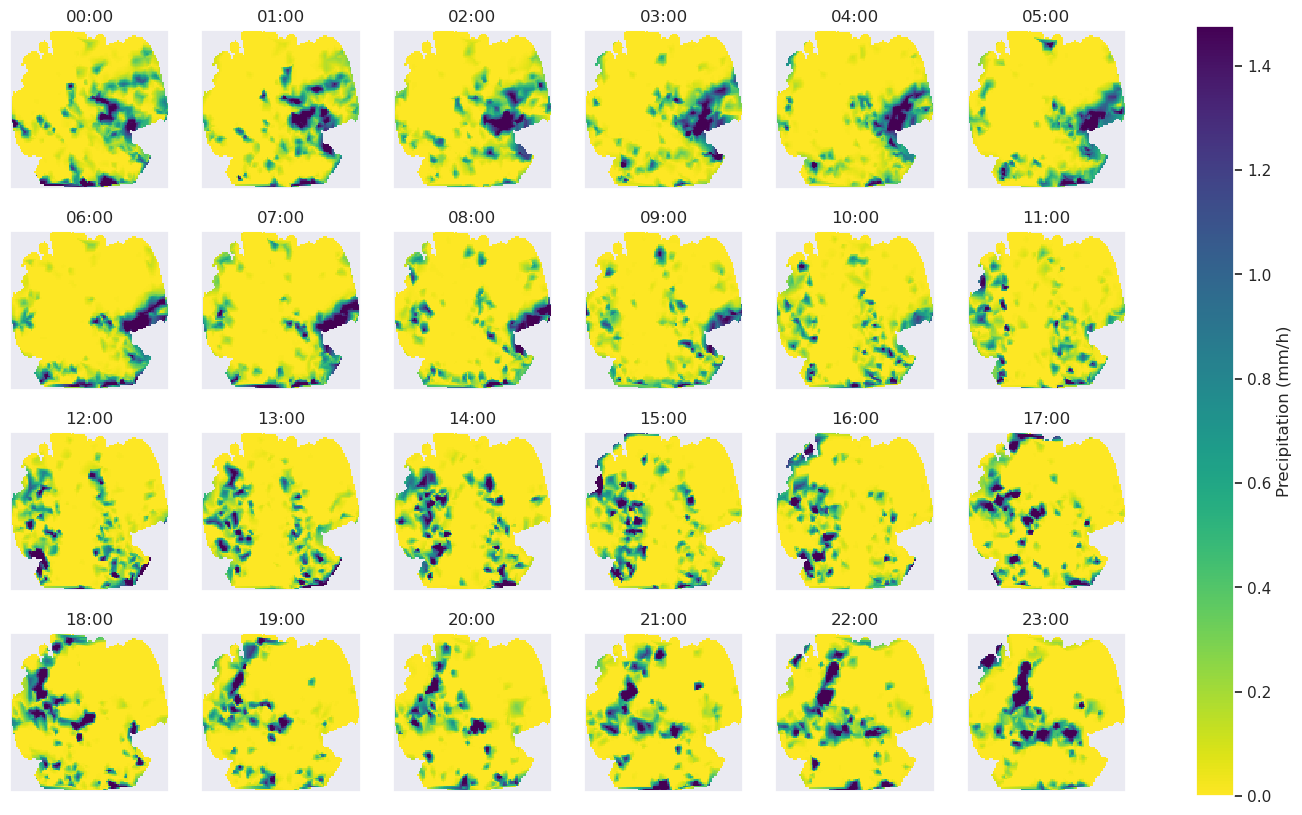

In [43]:
# 3.

# Loading grid data for interpolation:
grid = np.load("griddata.npz")
geolat = grid["geolat"]
geolong = grid["geolong"]
ind = grid["ind"].astype(bool)

# Extracting data for the 20th of April 2024:
day_df = precipation_df[precipation_df["date"] // 100 == 20240420].copy()
# Adding column for hour:
day_df["hour"] = day_df["date"] % 100

# Creating a container for interpolated values:
interpol_prec_day = np.full((24,) + geolat.shape, np.nan, dtype=float)

for h in range(24):
    # Extracting data for the current hour:
    sub = day_df[day_df["hour"] == h]
    lat = sub["geoBreite"].to_numpy(dtype=float).ravel()
    lon = sub["geoLaenge"].to_numpy(dtype=float).ravel()
    prec = sub["rain"].to_numpy(dtype=float).ravel()

    # Interpolation:
    points = np.column_stack([lon, lat])
    interpol_prec = griddata(
        points,
        prec,
        (geolong, geolat),
        method="linear",
    )
    # Masking out values outside of the convex hull of the data points:
    interpol_prec[~ind] = np.nan
    # Storing interpolated values for the current hour:
    interpol_prec_day[h] = interpol_prec

# Setting color range for the plot based on the 2nd and 98th percentile of the data to prevent outliers from dominating the color range:
prec_min = np.nanpercentile(interpol_prec_day, 2)
prec_max = np.nanpercentile(interpol_prec_day, 98)

fig, axes = plt.subplots(4, 6, figsize=(18, 10))
axes = axes.ravel()
im = None
for h, ax in enumerate(axes):
    im = ax.imshow(
        interpol_prec_day[h],
        origin="lower",         # Map pointing North.
        cmap="viridis_r",
        vmin=prec_min,
        vmax=prec_max,
        interpolation="nearest",
    )
    ax.set_title(f"{h:02d}:00")
    ax.set_xticks([])
    ax.set_yticks([])
cbar = fig.colorbar(im, ax=axes)
cbar.set_label("Precipitation (mm/h)")
plt.show()